# Principle Component Analysis

The application of this is very similar to TSVD: use SVD to get eigenvalues and vectors and then dump the eigenvectors with smaller eigenvalues. We have already done the hard work for this.

Let's include our libraries.

In [1]:
import numpy as np              #To make some operations easier
import matplotlib.pyplot as plt #To see what we are doing

Matplotlib is building the font cache; this may take a moment.


We need some data to play with, so let's re-make the 6D data we used in TVSD.

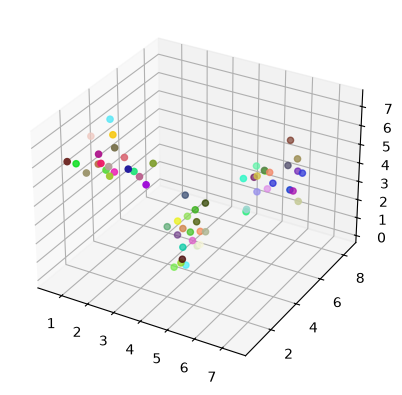

In [2]:
#While we play around, we want our results to be repeatable. So let's set a seed
np.random.seed(256)

#Draw 20 random points from a 3D Gaussian with
point_1 = np.random.multivariate_normal([2,2,6], [[0.75,0.00,0.00],[0.00,0.50,0.00],[0.00,0.00,0.25]], 20) #mean=[2,2,6] and std=[0.75,0.50,0.25]
point_2 = np.random.multivariate_normal([6,6,4], [[0.50,0.00,0.00],[0.00,0.75,0.00],[0.00,0.00,0.25]], 20) #mean=[6,6,4] and std=[0.50,0.75,0.25]
point_3 = np.random.multivariate_normal([4,4,2], [[0.25,0.00,0.00],[0.00,0.25,0.00],[0.00,0.00,0.75]], 20) #mean=[4,4,2] and std=[0.25,0.25,0.75]
points = np.vstack((point_1, point_2, point_3))
#Draw 3 values between 0 and 1 for each point (this are effectivly RGB colours, to help visualise 6D)
colour = np.random.uniform(low=[0,0,0], high=[1,1,1], size=[len(points),3]) #
X = np.hstack((points, colour))

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(X[:,0], X[:,1], X[:,2], color=X[:,3:])
plt.show()

Copy your get_U_Sigma_Vt_fixed(M) from TVSD, there is no point rewriting it at this point.

In [3]:
def get_U_Sigma_Vt_fixed(M):

    #####################
    B = np.dot(M.T, M)
    eigenvalues, eigenvectors = np.linalg.eig(B)
    eigenvalues = eigenvalues.real
    eigenvectors = eigenvectors.real
    
    col_order = np.argsort(eigenvalues)[::-1]
    V = eigenvectors[:,col_order]

    Sigma = np.sqrt(eigenvalues[col_order])

    U = np.dot(M, V)/Sigma

    #Have to trim U and Sigma to be the correct shape
    U = U[:M.shape[0], :M.shape[0]]
    Sigma = Sigma[:M.shape[0]]

    new_Sigma = np.zeros((M.shape[0], M.shape[1]))
    new_Sigma[:Sigma.shape[0], :Sigma.shape[0]] = np.diag(Sigma)
    Sigma = new_Sigma
    
    Vt = V.T
    #####################

    return U, Sigma, Vt

Unlike TSVD, we need to centre our data. The mean of the data is likely to be an important single value, and we don't really care about it.

We need to keep the means of the data if we want to embed more data into our low dimensional space.

In [4]:
def centre_data(X):

    #####################
    X_mu = np.mean(X, axis=0)
    X_centered = X - X_mu
    #####################

    return X_centered, X_mu

X_centered, X_mu = centre_data(X)

Now lets do some PCA down to 2D. We used __U__ __Σ__ in TSVD, so lets use __V__<sup>T</sup> this time. We need to do this on the centred data: __Z__ = __X__<sub>centred</sub>__V__

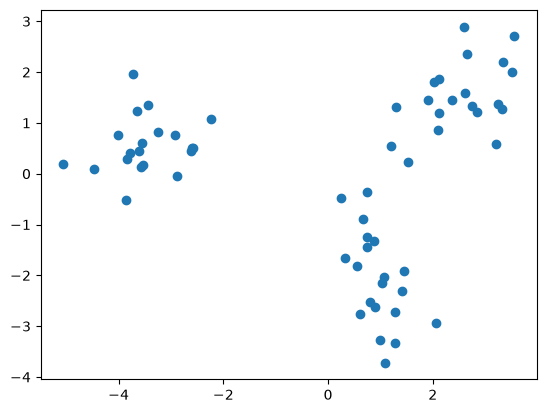

In [5]:
def pca(X, d=2):

    #####################
    X_centered, X_mu = centre_data(X)
    U, Sigma, Vt = get_U_Sigma_Vt_fixed(X_centered)
    Vt_d = Vt[:d]
    Z = np.dot(X_centered, Vt_d.T)
    #####################
    
    return Z, X_mu, Vt_d

Z, X_mu, Vt_d = pca(X)

plt.scatter(Z[:,0], Z[:,1])
plt.show()

Let's check our method against scikit learn's PCA.

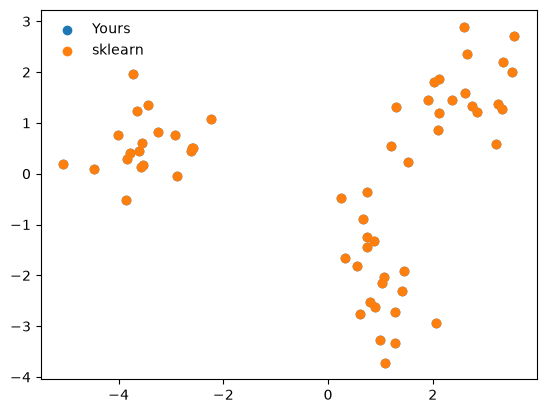

In [6]:
from sklearn.decomposition import PCA

skl_pca = PCA(n_components=2)
skl_pca.fit(X)
Z_skl = skl_pca.transform(X)

plt.scatter(Z[:,0], Z[:,1], label="Yours")
plt.scatter(Z_skl[:,0], Z_skl[:,1], label='sklearn')
plt.legend(loc=0, frameon=False)
plt.show()

If your points do not overlap with the ones from sklearn it is probably the signs on the eigenvalues again. Flip them around the axes and they should lign up.

Like with TSVD, we can use __V__<sub>_d_</sub> to put new data into our lower dimensional space. Lets gets some more toy data to drop into our new space.

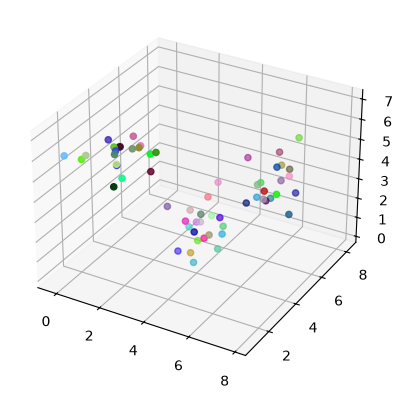

In [7]:
#Draw 20 random points from a 3D Gaussian with
point_1 = np.random.multivariate_normal([2,2,6], [[0.75,0.00,0.00],[0.00,0.50,0.00],[0.00,0.00,0.25]], 20) #mean=[2,2,6] and std=[0.75,0.50,0.25]
point_2 = np.random.multivariate_normal([6,6,4], [[0.50,0.00,0.00],[0.00,0.75,0.00],[0.00,0.00,0.25]], 20) #mean=[6,6,4] and std=[0.50,0.75,0.25]
point_3 = np.random.multivariate_normal([4,4,2], [[0.25,0.00,0.00],[0.00,0.25,0.00],[0.00,0.00,0.75]], 20) #mean=[4,4,2] and std=[0.25,0.25,0.75]
points = np.vstack((point_1, point_2, point_3))
#Draw 3 values between 0 and 1 for each point (this are effectivly RGB colours, to help visualise 6D)
colour = np.random.uniform(low=[0,0,0], high=[1,1,1], size=[len(points),3]) #
Y = np.hstack((points, colour))

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(Y[:,0], Y[:,1], Y[:,2], color=Y[:,3:])
plt.show()

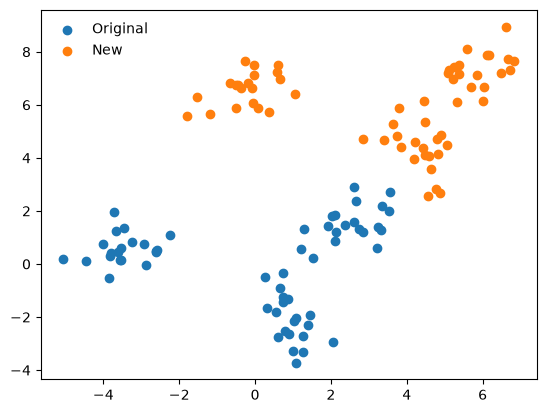

In [8]:
Z_Y = np.dot(Y, Vt_d.T)

plt.scatter(Z[:,0], Z[:,1], label='Original')
plt.scatter(Z_Y[:,0], Z_Y[:,1], label='New')
plt.legend(loc=0, frameon=False)
plt.show()

The orange points should be close to the blue points, but they are off. Remember to centre the data with __X__<sub>mu</sub> we saved. Let's try again.

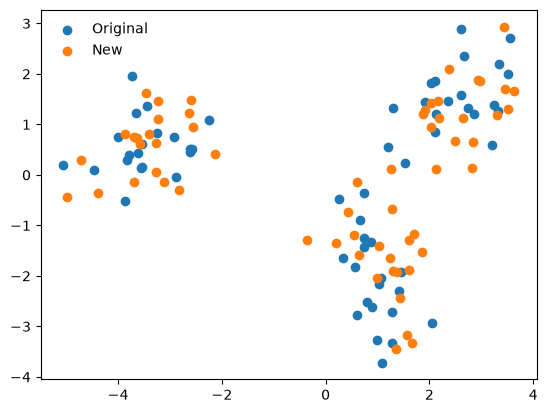

In [9]:
Z_Y = np.dot(Y-X_mu, Vt_d.T)

plt.scatter(Z[:,0], Z[:,1], label='Original')
plt.scatter(Z_Y[:,0], Z_Y[:,1], label='New')
plt.legend(loc=0, frameon=False)
plt.show()

That's more like it!

Let's save our Z data for this afternoon.

In [10]:
np.save('PCA_Z.npy', Z)

## Real Data

Now let's play with some real data! MorphologicalCat_VISTULA.csv contains morphologies for 10943 galaxies observed by KiDS. Let's grab that data!

In [11]:
#The first row is the header, so we will skip that
data = np.genfromtxt('MorphologicalCat_VISTULA.csv', dtype=float, delimiter=',')[1:]

Now run your PCA on the data.

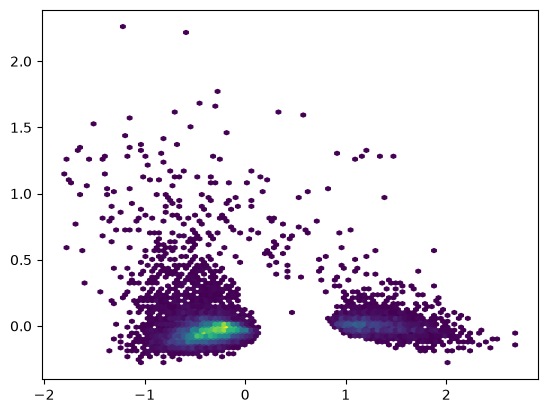

In [12]:
Z_data, X_mu, Vt_d = pca(data)
plt.hexbin(Z_data[:,0], Z_data[:,1], mincnt=1)
plt.show()

That looks like two clusters. Remember, the PCA axes don't really tell us anything in and of themselves. So we don't know what these clusters are from the x and y axes. We would need to find the members of the clusters and eximin them closer. Let's save this 2D reduction for now.

In [13]:
np.save('PCA_data.npy', Z_data)